In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
# Count number of images in each folder

train_real = len(os.listdir("dataset/train/real"))
train_fake = len(os.listdir("dataset/train/fake"))

test_real = len(os.listdir("dataset/test/real"))
test_fake = len(os.listdir("dataset/test/fake"))

# Print results

print("Train Real:", train_real)
print("Train Fake:", train_fake)
print("Test Real:", test_real)
print("Test Fake:", test_fake)

Train Real: 10
Train Fake: 9
Test Real: 4
Test Fake: 4


Using path: dataset/train/real
Files: ['.ipynb_checkpoints', 'real1.jpg', 'real2.jpg', 'real3.jpg', 'real4.jpg', 'real5.jpg', 'real6.jpg', 'real7.jpg', 'real8.jpg', 'real9.jpg']
Reading: dataset/train/real\real1.jpg
Reading: dataset/train/real\real2.jpg
Reading: dataset/train/real\real3.jpg


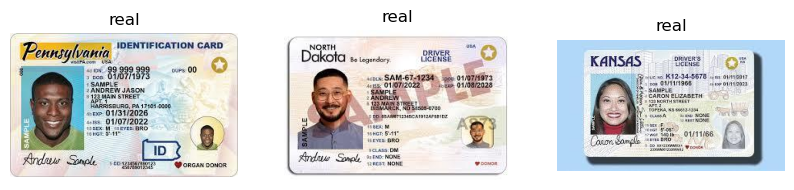

Using path: dataset/train/fake
Files: ['fake1.png', 'fake2.png', 'fake3.png', 'fake4.png', 'fake5.png', 'fake6.png', 'fake7.png', 'fake8.png', 'fake9.png']
Reading: dataset/train/fake\fake1.png
Reading: dataset/train/fake\fake2.png
Reading: dataset/train/fake\fake3.png


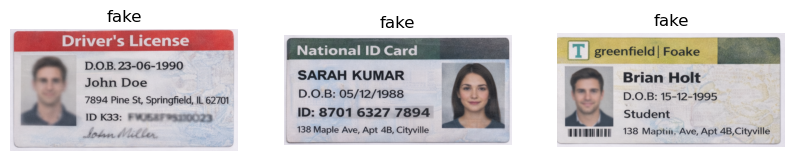

In [21]:
# -----------------------------
# DISPLAYING SAMPLE IMAGES
# -----------------------------

def show_samples(label):
    # Set path based on label (real/fake)
    path = f"dataset/train/{label}"

    # Print folder path and files (for checking)
    print("Using path:", path)
    print("Files:", os.listdir(path))

    # Filter only image files
    images = [img for img in os.listdir(path) 
              if img.lower().endswith(('.jpg', '.png', '.jpeg'))]

    # Check if folder is empty
    if len(images) == 0:
        print("No images found inside", path)
        return

    # Create figure for displaying images
    plt.figure(figsize=(10,3))

    # Loop through first 3 images
    for i, img_name in enumerate(images[:3]):
        full_path = os.path.join(path, img_name)
        print("Reading:", full_path)

        # Read image
        img = cv2.imread(full_path)

        # Check if image is valid
        if img is None:
            print("Cannot read:", img_name)
            continue

        # Convert BGR to RGB (for correct color display)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Show image in subplot
        plt.subplot(1,3,i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

    # Display all images
    plt.show()


# -----------------------------
# FUNCTION CALL
# -----------------------------

# Show real images
show_samples("real")

# Show fake images
show_samples("fake")

In [22]:
# -----------------------------
# ANALYZING IMAGE SIZES
# -----------------------------

# Create empty list to store image sizes
sizes = []

# Loop through both classes (real and fake)
for label in ["real", "fake"]:
    
    # Set path for each folder
    path = f"dataset/train/{label}"
    
    # Loop through all images in folder
    for img_name in os.listdir(path):
        
        # Read image
        img = cv2.imread(os.path.join(path, img_name))
        
        # Check if image is loaded properly
        if img is not None:
            
            # Store image size (height, width, channels)
            sizes.append(img.shape)

# Print first 5 image sizes
print(sizes[:5])

[(178, 283, 3), (182, 277, 3), (170, 296, 3), (179, 282, 3), (182, 277, 3)]


real average blur: 12212.000567951776
fake average blur: 669.5336521117472


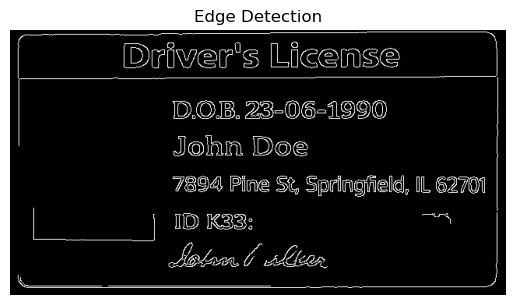

In [24]:
# -----------------------------
# EDGE DETECTION
# -----------------------------

# Read first image from fake folder
img = cv2.imread("dataset/train/fake/" + os.listdir("dataset/train/fake")[0])

# Convert image to grayscale (simplifies processing)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Canny edge detection
# 100 = lower threshold, 200 = upper threshold
edges = cv2.Canny(gray, 100, 200)

# Display edge-detected image
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis('off')  # Remove axis for clean view
plt.show()

In [2]:
# -----------------------------
# IMAGE DATA PREPROCESSING
# -----------------------------

# Import ImageDataGenerator for preprocessing and augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set image size for model input
IMG_SIZE = 128

# Set batch size (number of images processed at once)
BATCH_SIZE = 4

# Create training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values (0–255 → 0–1)
    rotation_range=10,     # Randomly rotate images
    zoom_range=0.1,        # Random zoom
    horizontal_flip=True   # Flip images horizontally
)

# Create test data generator (only normalization, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

C:\anaconda25\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
# LOADING TRAIN & TEST DATA

train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,# -----------------------------
# LOADING TRAIN & TEST DATA
# -----------------------------

# Load training data from folder
train_data = train_datagen.flow_from_directory(
    "dataset/train",                 # Path to training dataset
    target_size=(IMG_SIZE, IMG_SIZE),# Resize all images to 128x128
    batch_size=BATCH_SIZE,           # Number of images per batch
    class_mode='categorical'         # Convert labels to one-hot encoding
)

# Load testing data from folder
test_data = test_datagen.flow_from_directory(
    "dataset/test",                  # Path to testing dataset
    target_size=(IMG_SIZE, IMG_SIZE),# Resize images
    batch_size=BATCH_SIZE,           # Batch size
    class_mode='categorical'         # One-hot encoded labels
)
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 18 images belonging to 2 classes.
Found 6 images belonging to 2 classes.


In [6]:
# BUILDING CNN MODEL

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

In [7]:
# COMPILING THE CNN MODEL

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# TRAINING THE CNN MODEL

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.6667 - loss: 0.6842 - val_accuracy: 0.5000 - val_loss: 1.7169
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5556 - loss: 0.9895 - val_accuracy: 0.5000 - val_loss: 0.7030
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.3889 - loss: 0.8064 - val_accuracy: 0.5000 - val_loss: 0.7209
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.7222 - loss: 0.6689 - val_accuracy: 0.5000 - val_loss: 0.7505
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.6111 - loss: 0.6796 - val_accuracy: 0.5000 - val_loss: 0.7692
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.7778 - loss: 0.5423 - val_accuracy: 0.5000 - val_loss: 1.2044
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.7778 - loss: 0.4355 - val_accuracy: 0.5000 - val_loss: 1.1306
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.7778 - loss: 0.3496 - val_accuracy: 0.5000 - val_loss:

In [30]:
# VIEWING CLASS INDICES

print(train_data.class_indices)

{'.ipynb_checkpoints': 0, 'fake': 1, 'real': 2}


In [1]:
# REMOVING UNWANTED FOLDERS

import shutil

shutil.rmtree("dataset/train/.ipynb_checkpoints", ignore_errors=True)
shutil.rmtree("dataset/test/.ipynb_checkpoints", ignore_errors=True)

print("Deleted hidden folders")

Deleted hidden folders


In [9]:
# EVALUATING MODEL PERFORMANCE

loss, acc = model.evaluate(test_data)
print("Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5000 - loss: 0.9201 
Accuracy: 0.5


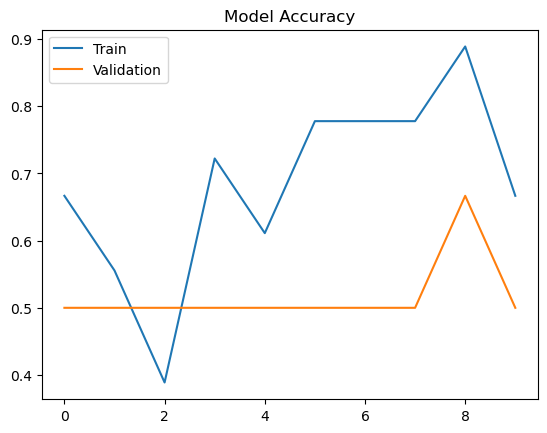

In [12]:
# PLOTTING MODEL ACCURACY

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [13]:
# IMAGE PREDICTION FUNCTION

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.reshape(img, (1,128,128,3))
    
    prediction = model.predict(img)
    
    return "Real" if np.argmax(prediction)==0 else "Fake"

In [16]:
# SAVING THE TRAINED MODEL

model.save("id_forgery_model.h5")